# SWaT Experiments

## Load Data

In [1]:
# Load swat data
from bdm.Experiments.data_loader import swat_data

train_df, test_df, signal_variables, control_variables, dict_continuous_variables, dict_discrete_variables = swat_data()
train_df = train_df.drop(["Timestamp", "Normal/Attack"], axis=1)
print(train_df.values.shape, test_df.values.shape)

(99360, 51) (89984, 54)


In [2]:
# Prepare data for RS
import numpy as np

x = train_df.values

x -= np.mean(x, axis=0, keepdims=True)
x[:, np.std(x, axis=0) > 0] /= np.std(x, axis=0, keepdims=True)[:, np.std(x, axis=0) > 0]

x = np.nan_to_num(x, nan=0)

# Used 480 for some reason
x_esn_fit = x[:1200]
x_rhy_fit = x[480-100-200-100:480+200]

## Find hyperparams

In [3]:
# Find hp

from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for iw in np.linspace(0.1, 0.2, 10): # np.linspace(0.1, 0.5, 10):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=0.5,
        input_weight=iw,
        average_degree_nodes=8,
        num_nodes=768, #512,
        leakage=0,
        # Rhythmic params
        link_strength_change_ratio=0
    )
    
    for sr in tqdm(np.linspace(0.1, 0.2, 10)): # tqdm(np.linspace(0.1, 0.5, 10)):
        for l in np.linspace(0.4, 0.5, 10): # np.linspace(0.25, 0.5, 10):
            network.change_spectral_rad_and_leakage(sr, l)

            network.train(x_esn_fit.T[:, :-200])
            pred = network.predict(x_esn_fit.T[:, -300:], warmup_time=100)
            mse = np.mean(np.square((pred[:, 1:] - x_esn_fit.T[:, -200:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
            if mse > 100_000_000:
                network.lsqrs = not network.lsqrs
        
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

  0%|                                                                                           | 0/10 [00:02<?, ?it/s]


KeyboardInterrupt: 

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr
New best 0.0005827017 (np.float64(0.25), np.float64(-0.1), np.float64(0.3), np.float64(0.01))


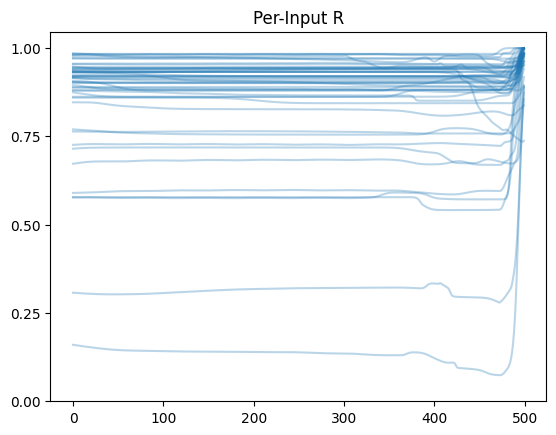

New best 0.0012090890 (np.float64(0.25), np.float64(-0.1), np.float64(0.37777777777777777), np.float64(0.01))


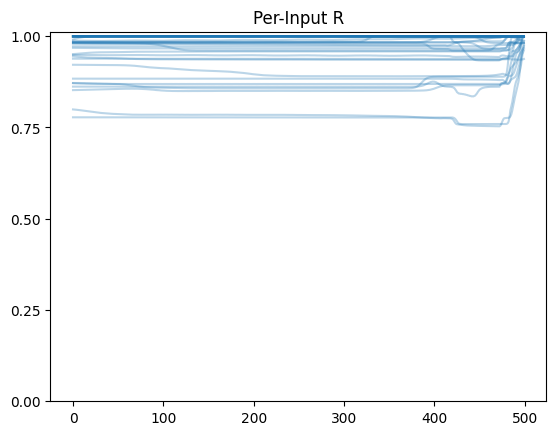

New best 0.0059066011 (np.float64(0.25), np.float64(-0.1), np.float64(0.5333333333333333), np.float64(0.01))


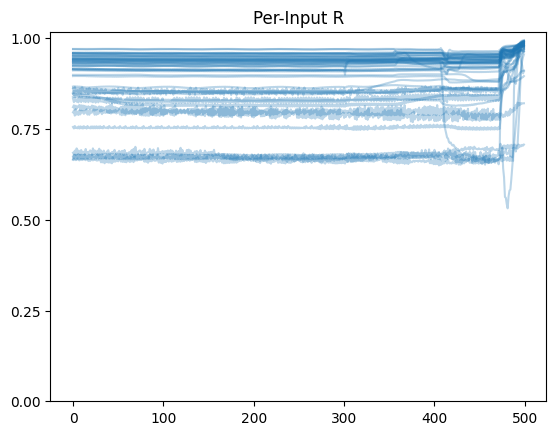

New best 0.0112877323 (np.float64(0.25), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.01))


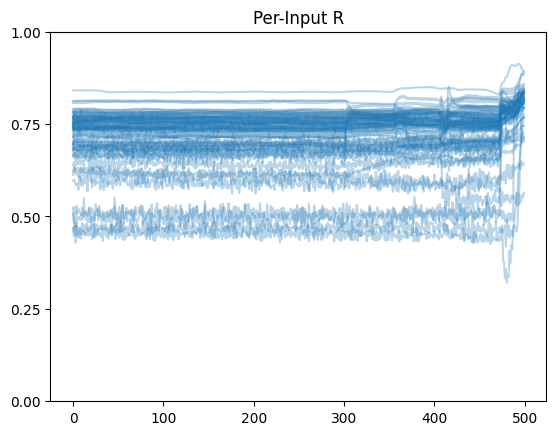

New best 0.0117523414 (np.float64(0.3333333333333333), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.01))


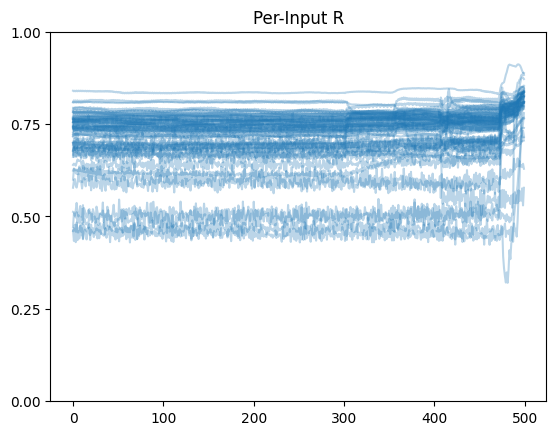

New best 0.0120624453 (np.float64(0.41666666666666663), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.01))


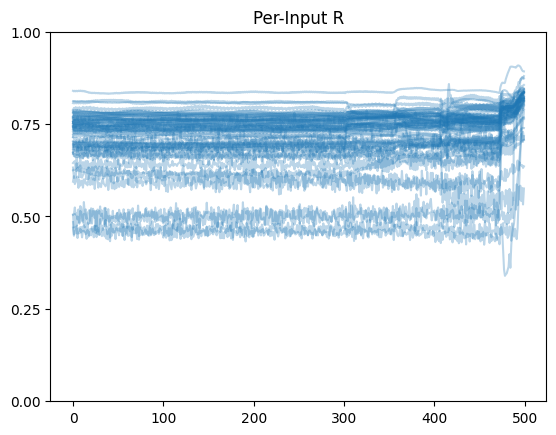

 10%|███████▉                                                                       | 1/10 [27:54<4:11:14, 1674.98s/it]

New best 0.0127015452 (np.float64(0.25), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.01))


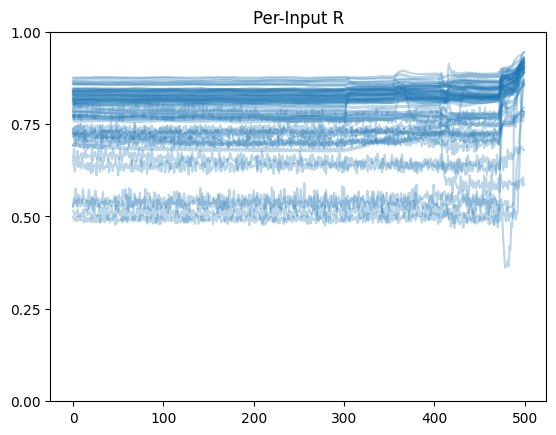

New best 0.0127543432 (np.float64(0.3333333333333333), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.01))


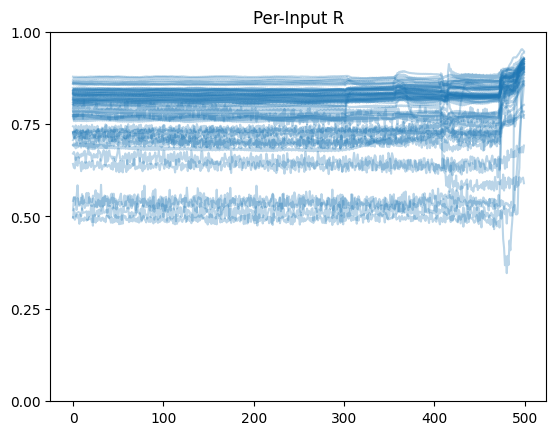

 40%|██████████████████████████████▊                                              | 4/10 [1:50:45<2:45:59, 1659.96s/it]

New best 0.0130065871 (np.float64(0.41666666666666663), np.float64(-0.14444444444444446), np.float64(0.6888888888888889), np.float64(0.01))


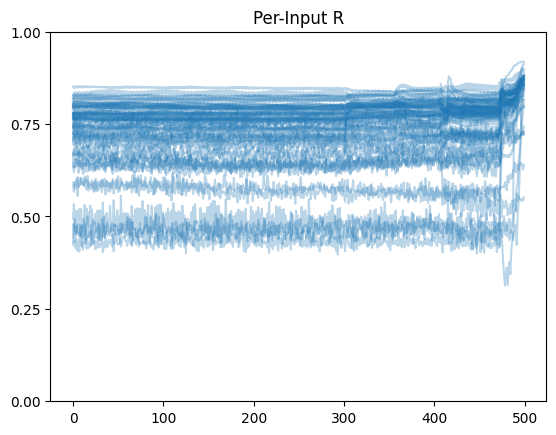

New best 0.0130973140 (np.float64(0.5833333333333333), np.float64(-0.14444444444444446), np.float64(0.6888888888888889), np.float64(0.01))


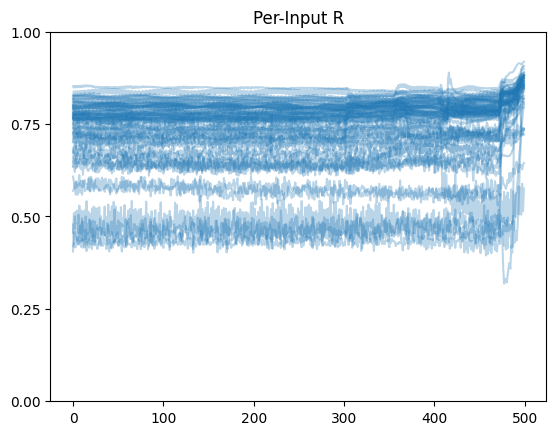

New best 0.0133721245 (np.float64(0.6666666666666666), np.float64(-0.14444444444444446), np.float64(0.6888888888888889), np.float64(0.01))


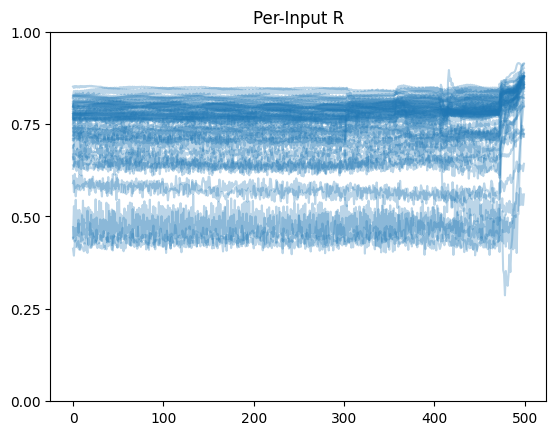

New best 0.0135150559 (np.float64(0.75), np.float64(-0.14444444444444446), np.float64(0.6888888888888889), np.float64(0.01))


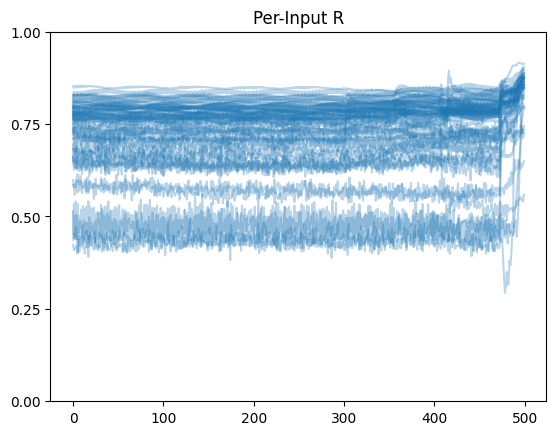

New best 0.0140486969 (np.float64(1.0), np.float64(-0.14444444444444446), np.float64(0.6888888888888889), np.float64(0.01))


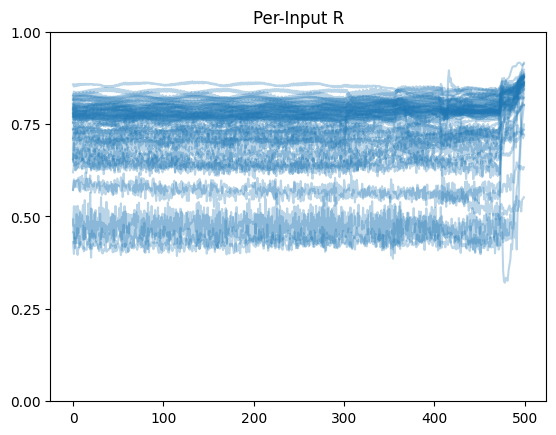

 70%|█████████████████████████████████████████████████████▉                       | 7/10 [3:21:05<1:29:02, 1780.74s/it]

New best 0.0141517206 (np.float64(1.0), np.float64(-0.17777777777777778), np.float64(0.7666666666666666), np.float64(0.01))


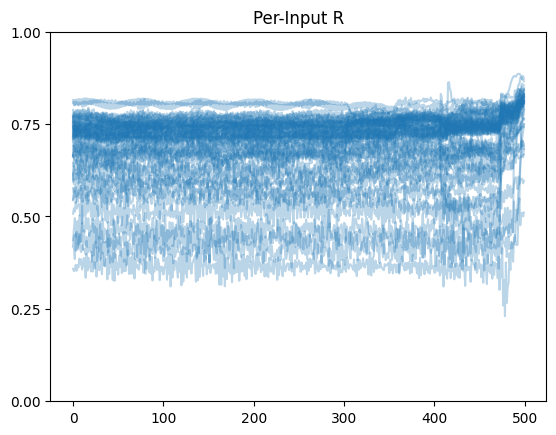

 80%|███████████████████████████████████████████████████████████████▏               | 8/10 [3:47:28<57:15, 1717.91s/it]

New best 0.0146156080 (np.float64(0.25), np.float64(-0.1888888888888889), np.float64(0.7666666666666666), np.float64(0.01))


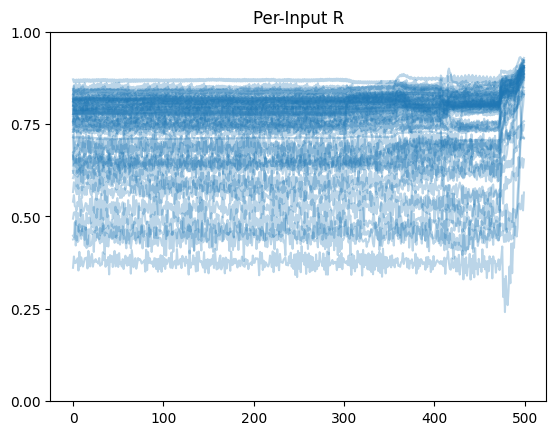

New best 0.0148423206 (np.float64(0.5), np.float64(-0.1888888888888889), np.float64(0.7666666666666666), np.float64(0.01))


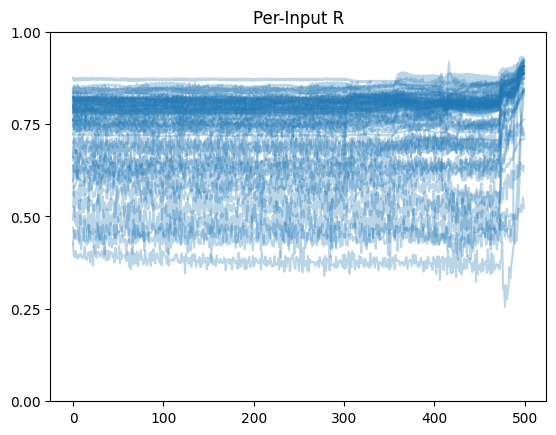

New best 0.0152708095 (np.float64(0.5833333333333333), np.float64(-0.1888888888888889), np.float64(0.7666666666666666), np.float64(0.01))


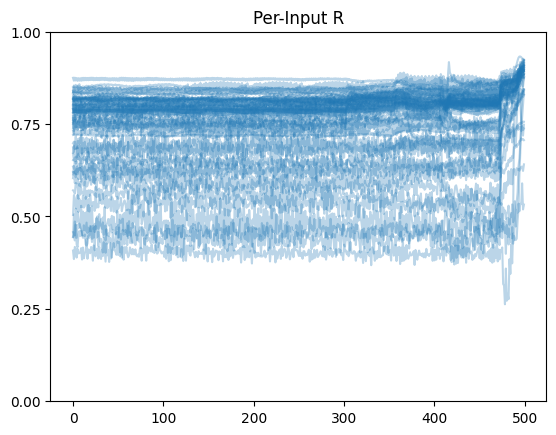

New best 0.0154848899 (np.float64(0.6666666666666666), np.float64(-0.1888888888888889), np.float64(0.7666666666666666), np.float64(0.01))


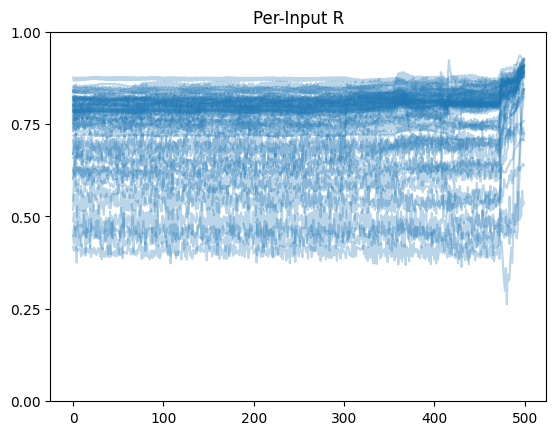

New best 0.0156633390 (np.float64(0.75), np.float64(-0.1888888888888889), np.float64(0.7666666666666666), np.float64(0.01))


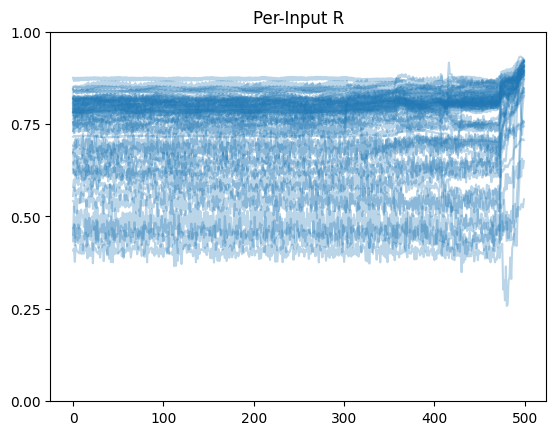

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


 50%|██████████████████████████████████████▌                                      | 5/10 [3:57:10<3:57:10, 2846.05s/it]


KeyboardInterrupt: 

In [7]:
import matplotlib.pyplot as plt

best_difference = 0

for o in np.linspace(0.01, 0.4, 10): # np.linspace(0.25, 0.35, 10):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=best_esn_param[0],
        input_weight=best_esn_param[1],
        average_degree_nodes=8,
        num_nodes=768,
        leakage=best_esn_param[2],
        # Rhythmic params
        link_strength_change_ratio=0,
        omega0=o,
        epsilon1=0,
        epsilon2=0,
    )
    
    for e1 in tqdm(np.linspace(-0.2, -0.1, 10)[::-1]): #tqdm(np.linspace(-0.15, -0.06, 10)[::-1]):
        for lsr in np.linspace(0.25, 1, 10): # np.linspace(0.8, 1, 10):
            for e2 in np.linspace(0.3, 1.0, 10): # np.linspace(0.5, .7, 10):
                network.epsilon1 = e1
                network.epsilon2 = e2
                network.link_strength_change_ratio = lsr
                network.reset_initial_states()
                network.reset_history()
                
                network.train(x_rhy_fit.T, warmup_time=100)
                r = network.get_global_parameters()[0]
    
                # diff = np.std(r.T[:200])/np.std(r.T[-200:])
                diff = np.abs(np.mean(r.T[-400:-200]) - np.mean(r.T[-200:])) #/np.mean(r.T[:250])
                
                if diff > best_difference and np.mean(r.T[-400:-200]) > 0.5: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T, color="tab:blue", alpha=0.3)
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [4]:
# Presaved params

best_esn_param = (0.19, 0.1, 0.41) # (0.14, 0.1, 0.4) # best_esn_param = (0.14, 0.1, 0.42) # best_esn_param = (0.37, 0.32, 0.44)
best_param_rhy = (0.75, -0.19, 0.77, 0.01) # best_param_rhy = (0.82, -0.15, 0.7, 0.31) # best_param_rhy = (0.83, -0.11, 0.63, 0.29) # best_param_rhy = (1.0, -0.1, 0.53, 0.31)

## Run data through RS

In [5]:
# Run network on train_df
from scipy.ndimage import median_filter

network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=768,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T)
train_r = network.get_input_parameters()[0].T
# train_r = median_filter(train_r, size=16, axes=[0])
assert np.max(train_r, axis=0, keepdims=True).shape[1] == x.shape[1]
train_r = (train_r - np.min(train_r, axis=0, keepdims=True))/(np.max(train_r, axis=0, keepdims=True) - np.min(train_r, axis=0, keepdims=True))

100%|████████████████████████████████████████████████████████████████████████████| 99360/99360 [38:46<00:00, 42.71it/s]


In [6]:
# Load test_df
x = test_df.values[:, 1:-2].astype(float)

x -= np.mean(x, axis=0, keepdims=True)
x[:, np.std(x, axis=0) > 0] /= np.std(x, axis=0, keepdims=True)[:, np.std(x, axis=0) > 0]

x = np.nan_to_num(x, nan=0)
x.shape

(89984, 51)

In [7]:
# Run network on test_df
network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=768,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T)
test_r = network.get_input_parameters()[0].T
# test_r = median_filter(test_r, size=16, axes=[0])
assert np.max(test_r, axis=0, keepdims=True).shape[1] == x.shape[1]
test_r = (test_r - np.min(test_r, axis=0, keepdims=True))/(np.max(test_r, axis=0, keepdims=True) - np.min(test_r, axis=0, keepdims=True))

100%|████████████████████████████████████████████████████████████████████████████| 89984/89984 [34:46<00:00, 43.12it/s]


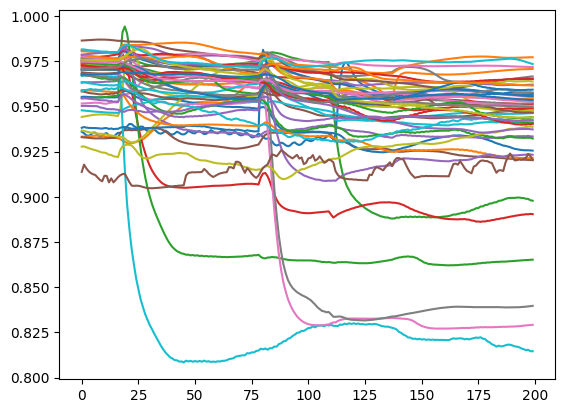

In [8]:
# Plot example from test
import matplotlib.pyplot as plt

plt.plot(test_r[919:1119])
plt.show()

## BDM

In [9]:
# Train bdm
# import keras
# keras.config.set_backend("tensorflow")

import bdm.Algorithm.BDM as new_bdm
import pandas as pd

new_train_df = pd.DataFrame(train_r, columns=train_df.columns).astype(float)

xl = 8
ul = xl * 2
batch_size = 256
bdm = new_bdm.BDM(x_length=xl, u_length=ul)
epochs = 250

x_prev, x_curr, x_next, u_curr, _ = bdm.prepare_data(
    new_train_df, signal_variables=signal_variables,
    control_variables=control_variables, dict_continuous_variables=dict_continuous_variables,
    dict_discrete_variables=dict_discrete_variables, label=None, normalization=None, freq=1
)

x_dim = int(x_curr.shape[1]/xl)
index = np.arange(len(x_prev))
train_pos = index[:(len(x_prev) * 3 // 4)]
val_pos = index[(len(x_prev) * 3 // 4):]

x_train_bdm = [x_prev[train_pos, :], x_curr[train_pos, :], x_next[train_pos, :], u_curr[train_pos, :]]
x_val_bdm = [x_prev[val_pos, :], x_curr[val_pos, :], x_next[val_pos, :], u_curr[val_pos, :]]

bdm.train(x_train_bdm, s_dim=4, s_activation='tanh', batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=2)

Epoch 1/250
262/262 - 18s - 68ms/step - functional_1_loss: 0.3329 - functional_loss: 0.2546 - loss: 1.0440 - subtract_1_loss: 0.0217 - subtract_loss: 0.0259 - val_functional_1_loss: 0.0286 - val_functional_loss: 0.3140 - val_loss: 0.1246 - val_subtract_1_loss: 0.0126 - val_subtract_loss: 0.0072
Epoch 2/250
262/262 - 4s - 16ms/step - functional_1_loss: 0.0099 - functional_loss: 0.1588 - loss: 0.0491 - subtract_1_loss: 0.0078 - subtract_loss: 0.0075 - val_functional_1_loss: 0.0029 - val_functional_loss: 0.0601 - val_loss: 0.0159 - val_subtract_1_loss: 0.0026 - val_subtract_loss: 0.0033
Epoch 3/250
262/262 - 4s - 16ms/step - functional_1_loss: 0.0025 - functional_loss: 0.0295 - loss: 0.0112 - subtract_1_loss: 0.0016 - subtract_loss: 0.0018 - val_functional_1_loss: 8.6713e-04 - val_functional_loss: 0.0118 - val_loss: 0.0041 - val_subtract_1_loss: 6.3532e-04 - val_subtract_loss: 4.8692e-04
Epoch 4/250
262/262 - 4s - 16ms/step - functional_1_loss: 0.0015 - functional_loss: 0.0062 - loss: 0.0

In [10]:
# Test bdm
from bdm.Algorithm.utils import f_search
from sklearn import metrics

bdm.estimate_system(x_val_bdm)

new_test_df = pd.DataFrame(
    np.concatenate([test_r, test_df.values[:, -1:]], axis=1),
    columns=list(test_df.columns[1:-2]) + [test_df.columns[-1]]
).astype(float)

_, x_curr, _, u_curr, labels = bdm.prepare_data(
    new_test_df, signal_variables=signal_variables,
    control_variables=control_variables, dict_continuous_variables=dict_continuous_variables,
    dict_discrete_variables=dict_discrete_variables, label='label', normalization=None, freq=xl
)

test_x_bdm = x_curr; test_u_bdm = u_curr

z_scores_bdm = bdm.test(test_x_bdm, test_u_bdm)
z_scores_bdm = np.nan_to_num(z_scores_bdm)
t, _ = f_search(z_scores_bdm, labels[1:])

print('BDM')
print('best-f1', t[0]) # Before removing > 0.7, this was 0.75
print('precision', t[1])
print('recall', t[2])
print('accuracy', (t[3] + t[4]) / (t[3] + t[4] + t[5] + t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print('AUC:', metrics.roc_auc_score(labels[1:], z_scores_bdm))

777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
BDM
best-f1 0.7627715141497821
precision 0.8045052228117038
recall 0.725163156452769
accuracy 0.9446865273454869
TP 1000.0
TN 9623.0
FP 243.0
FN 379.0
AUC: 0.897558244949326


## NSIBF

In [11]:
# Setup NSIBF
import os, sys
sys.path.append(os.path.abspath("NSIBF"))

import NSIBF.framework.models as models
from NSIBF.framework.HPOptimizer.Hyperparameter import UniformIntegerHyperparameter,ConstHyperparameter, UniformFloatHyperparameter
from NSIBF.framework.HPOptimizer import HPOptimizers
from NSIBF.framework.preprocessing import normalize_and_encode_signals
from NSIBF.framework.preprocessing.signals import SignalSource, ContinousSignal
from NSIBF.framework.utils.metrics import bf_search
from NSIBF.framework.utils import negative_sampler

signals = []
for c in list(test_df.columns[1:-2]):
    signals.append(ContinousSignal(c, SignalSource.sensor, isInput=True, isOutput=True, min_value=0, max_value=1))

seqL = 12
kf = models.NSIBF(signals, window_length=seqL, input_range=seqL*3)

pos = len(new_train_df)*3//4
nsibf_val_df = new_train_df.loc[pos:,:]
nsibf_val_df = nsibf_val_df.reset_index(drop=True)

nsibf_train_df = new_train_df.loc[:pos,:]
nsibf_train_df = nsibf_train_df.reset_index(drop=True)

nsibf_train_df = normalize_and_encode_signals(nsibf_train_df, signals, scaler='min_max')
train_x,train_u,train_y,_ = kf.extract_data(nsibf_train_df)
x_train = [train_x,train_u]
y_train = [train_x,train_y]

x,u,y = [],[],[]
for i in range(20):
    r = 0.05*i
    negative_df = negative_sampler.apply_negative_samples(nsibf_val_df, signals, sample_ratio=r, sample_delta=0.05)
    negative_df = normalize_and_encode_signals(negative_df,signals,scaler='min_max')
    neg_x,neg_u,_,neg_labels = kf.extract_data(negative_df,purpose='AD',freq=seqL,label='class_label')
    neg_labels = neg_labels.sum(axis=1)
    neg_labels[neg_labels<seqL]=0
    neg_labels[neg_labels==seqL]=1
    x.append(neg_x)
    u.append(neg_u)
    y.append(neg_labels)
x = np.concatenate(x)
u = np.concatenate(u)
y = np.concatenate(y)
print(list(y).count(1),len(y))
x_neg = [x,u]
y_neg = y

4561 41360


In [12]:
# Train NSIBF

hp_list = []
hp_list.append(UniformIntegerHyperparameter('z_dim',1,75)) 
hp_list.append(UniformIntegerHyperparameter('hnet_hidden_layers',1,3))  
hp_list.append(UniformIntegerHyperparameter('fnet_hidden_layers',1,3))
hp_list.append(UniformIntegerHyperparameter('fnet_hidden_dim',32,256))
hp_list.append(UniformIntegerHyperparameter('uencoding_layers',1,3))
hp_list.append(UniformIntegerHyperparameter('uencoding_dim',32,256))
hp_list.append(UniformFloatHyperparameter('l2',0,0.05))
hp_list.append(ConstHyperparameter('epochs',25))
hp_list.append(ConstHyperparameter('save_best_only',True))
hp_list.append(ConstHyperparameter('validation_split',0.1))
hp_list.append(ConstHyperparameter('batch_size',256*8))
hp_list.append(ConstHyperparameter('verbose',2))

optor = HPOptimizers.RandomizedGS(kf, hp_list,x_train, y_train,x_neg,y_neg)
kf,optHPCfg,bestScore = optor.run(n_searches=10,verbose=1)


Epoch 1/25
33/33 - 25s - 748ms/step - h_net_loss: 0.7908 - loss: 158.4750 - smoothing_loss: 0.0507 - val_h_net_loss: 0.5832 - val_loss: 7.6569 - val_smoothing_loss: 0.0025
Epoch 2/25
33/33 - 20s - 597ms/step - h_net_loss: 0.2462 - loss: 3.1666 - smoothing_loss: 9.8587e-04 - val_h_net_loss: 0.0090 - val_loss: 0.8044 - val_smoothing_loss: 2.9246e-04
Epoch 3/25
33/33 - 20s - 601ms/step - h_net_loss: 0.0054 - loss: 0.9399 - smoothing_loss: 3.1546e-04 - val_h_net_loss: 6.7046e-04 - val_loss: 0.5628 - val_smoothing_loss: 2.0426e-04
Epoch 4/25
33/33 - 20s - 610ms/step - h_net_loss: 0.0017 - loss: 0.8161 - smoothing_loss: 2.7577e-04 - val_h_net_loss: 6.5907e-04 - val_loss: 0.5268 - val_smoothing_loss: 1.9023e-04
Epoch 5/25
33/33 - 21s - 622ms/step - h_net_loss: 0.0016 - loss: 0.7587 - smoothing_loss: 2.5617e-04 - val_h_net_loss: 6.9471e-04 - val_loss: 0.5004 - val_smoothing_loss: 1.8058e-04
Epoch 6/25
33/33 - 21s - 637ms/step - h_net_loss: 0.0016 - loss: 0.7070 - smoothing_loss: 2.3869e-04 - 

score: 0.5823530357563623 {'z_dim': 71, 'hnet_hidden_layers': 1, 'fnet_hidden_layers': 2, 'fnet_hidden_dim': 243, 'uencoding_layers': 1, 'uencoding_dim': 195, 'l2': 0.020365134082658127, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
33/33 - 68s - 2s/step - h_net_loss: 0.7921 - loss: 226.6491 - smoothing_loss: 0.1493 - val_h_net_loss: 0.5585 - val_loss: 74.8417 - val_smoothing_loss: 0.0525
Epoch 2/25
33/33 - 61s - 2s/step - h_net_loss: 0.2268 - loss: 23.4668 - smoothing_loss: 0.0151 - val_h_net_loss: 0.0045 - val_loss: 1.7739 - val_smoothing_loss: 0.0014
Epoch 3/25
33/33 - 66s - 2s/step - h_net_loss: 0.0052 - loss: 1.1178 - smoothing_loss: 7.4211e-04 - val_h_net_loss: 9.5783e-04 - val_loss: 0.3829 - val_smoothing_loss: 2.7888e-04
Epoch 4/25
33/33 - 60s - 2s/step - h_net_loss: 0.0018 - loss: 0.5280 - smoothing_loss: 3.5336e-04 - val_h_net_loss: 6.3419e-04 - val_loss: 0.3443 - val_smoothing_loss: 2.4464e-04
Epoch 5/25
33/33 - 6

score: 0.6038878506678427 {'z_dim': 23, 'hnet_hidden_layers': 1, 'fnet_hidden_layers': 3, 'fnet_hidden_dim': 112, 'uencoding_layers': 2, 'uencoding_dim': 245, 'l2': 0.032133554072280225, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
33/33 - 45s - 1s/step - h_net_loss: 0.7871 - loss: 20.5027 - smoothing_loss: 0.0752 - val_h_net_loss: 0.5759 - val_loss: 1.7334 - val_smoothing_loss: 0.0053
Epoch 2/25
33/33 - 37s - 1s/step - h_net_loss: 0.2447 - loss: 0.6347 - smoothing_loss: 0.0017 - val_h_net_loss: 0.0113 - val_loss: 0.1067 - val_smoothing_loss: 3.8888e-04
Epoch 3/25
33/33 - 39s - 1s/step - h_net_loss: 0.0054 - loss: 0.0960 - smoothing_loss: 3.7206e-04 - val_h_net_loss: 6.4189e-04 - val_loss: 0.0481 - val_smoothing_loss: 2.0624e-04
Epoch 4/25
33/33 - 37s - 1s/step - h_net_loss: 0.0017 - loss: 0.0719 - smoothing_loss: 2.8905e-04 - val_h_net_loss: 6.7570e-04 - val_loss: 0.0423 - val_smoothing_loss: 1.8055e-04
Epoch 5/25
33/33 - 

score: 0.6150404841134299 {'z_dim': 38, 'hnet_hidden_layers': 2, 'fnet_hidden_layers': 1, 'fnet_hidden_dim': 137, 'uencoding_layers': 2, 'uencoding_dim': 82, 'l2': 0.004321379965210803, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
33/33 - 29s - 885ms/step - h_net_loss: 0.3968 - loss: 42.1096 - smoothing_loss: 0.0236 - val_h_net_loss: 0.0240 - val_loss: 0.5727 - val_smoothing_loss: 3.0590e-04
Epoch 2/25
33/33 - 25s - 771ms/step - h_net_loss: 0.0051 - loss: 0.2337 - smoothing_loss: 1.3587e-04 - val_h_net_loss: 0.0022 - val_loss: 0.0631 - val_smoothing_loss: 4.0235e-05
Epoch 3/25
33/33 - 43s - 1s/step - h_net_loss: 0.0020 - loss: 0.0485 - smoothing_loss: 2.6966e-05 - val_h_net_loss: 7.8568e-04 - val_loss: 0.0239 - val_smoothing_loss: 1.4158e-05
Epoch 4/25
33/33 - 26s - 774ms/step - h_net_loss: 0.0017 - loss: 0.0348 - smoothing_loss: 1.9362e-05 - val_h_net_loss: 7.3642e-04 - val_loss: 0.0244 - val_smoothing_loss: 1.4521e-05
Epo

score: 0.6196677743301443 {'z_dim': 36, 'hnet_hidden_layers': 3, 'fnet_hidden_layers': 1, 'fnet_hidden_dim': 106, 'uencoding_layers': 1, 'uencoding_dim': 160, 'l2': 0.026314142419829562, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
33/33 - 18s - 537ms/step - h_net_loss: 0.5076 - loss: 91.0132 - smoothing_loss: 0.0380 - val_h_net_loss: 0.0809 - val_loss: 1.4147 - val_smoothing_loss: 5.2308e-04
Epoch 2/25
33/33 - 15s - 449ms/step - h_net_loss: 0.0144 - loss: 0.4958 - smoothing_loss: 1.8748e-04 - val_h_net_loss: 6.9248e-04 - val_loss: 0.1236 - val_smoothing_loss: 5.2579e-05
Epoch 3/25
33/33 - 15s - 449ms/step - h_net_loss: 0.0016 - loss: 0.1369 - smoothing_loss: 5.4294e-05 - val_h_net_loss: 6.3912e-04 - val_loss: 0.0720 - val_smoothing_loss: 3.0906e-05
Epoch 4/25
33/33 - 15s - 452ms/step - h_net_loss: 0.0014 - loss: 0.1155 - smoothing_loss: 4.5791e-05 - val_h_net_loss: 6.9472e-04 - val_loss: 0.0680 - val_smoothing_loss: 2.8878

score: 0.5462177514149099 {'z_dim': 15, 'hnet_hidden_layers': 2, 'fnet_hidden_layers': 3, 'fnet_hidden_dim': 247, 'uencoding_layers': 1, 'uencoding_dim': 219, 'l2': 0.004039779048808767, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}


In [ ]:
# Test NSIBF

nsibf_val_df = normalize_and_encode_signals(nsibf_val_df, signals, scaler='min_max') 
val_x,val_u,val_y,_ = kf.extract_data(nsibf_val_df)

nsibf_test_df = normalize_and_encode_signals(new_test_df,signals,scaler='min_max')
test_x,test_u,_,labels = kf.extract_data(nsibf_test_df, purpose='AD', freq=seqL,label='label')
labels = labels.sum(axis=1)
labels[labels>0]=1

kf.estimate_noise(val_x,val_u,val_y)

z_scores = kf.score_samples(test_x, test_u,reset_hidden_states=True)
# np.savetxt('../results/SWAT/NSIBF_scores',z_scores)
# z_scores = np.loadtxt('../results/SWAT/NSIBF_scores')
recon_scores,pred_scores = kf.score_samples_via_residual_error(test_x,test_u)

z_scores = np.nan_to_num(z_scores)

775/775 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
3 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
6 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
10 / 7496
3/3 ━━━━━━━━━━━━━━━━

In [17]:
t, th = bf_search(z_scores, labels[1:],start=0,end=np.percentile(z_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()
 
t, th = bf_search(recon_scores[1:], labels[1:],start=0,end=np.percentile(recon_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF-RECON')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()
 
t, th = bf_search(pred_scores, labels[1:],start=0,end=np.percentile(pred_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF-PRED')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()

# del nsibf_test_df, nsibf_train_df, nsibf_val_df, train_x, train_u, train_y, val_x, val_u, val_y, kf, HPOptimizers

NSIBF
best-f1 0.8805570933934704
precision 0.9703225681248702
recall 0.8060021349838999
accuracy 0.9727818545697131
TP 752.0
TN 6539.0
FP 23.0
FN 181.0

NSIBF-RECON
best-f1 0.8626710914331055
precision 0.9533073806315515
recall 0.7877813420387852
accuracy 0.9687791861240828
TP 735.0
TN 6526.0
FP 36.0
FN 198.0

NSIBF-PRED
best-f1 0.8875896691591696
precision 0.971938763113026
recall 0.8167202484810263
accuracy 0.9742494996664443
TP 762.0
TN 6540.0
FP 22.0
FN 171.0



## Driftbench

In [15]:
# Test using driftbench
from drift_helpers import added_detectors 
from drift_helpers import added_metrics

from driftbench.drift_detection.detectors import (
    RandomGuessDetector,
    RollingMeanDifferenceDetector,
    RollingMeanStandardDeviationDetector,
    AggregateFeatureAlgorithm,
    SlidingKSWINDetector,
    ClusterDetector,
    AutoencoderDetector,
    MMDDetector,
)
from driftbench.drift_detection.metrics import (
    TemporalAUC,
    SoftTAUC,
    AUC,
)

from river.drift import ADWIN, KSWIN, PageHinkley

detectors = [
    # Detectors from driftbench
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=50,
        batch_size=200,
        lr=0.001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=100,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=MMDDetector(window_size=20, stat_size=20, offset=10),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    MMDDetector(window_size=20, stat_size=20, offset=10),
    MMDDetector(window_size=40, stat_size=40, offset=10),
    RollingMeanDifferenceDetector(window_size=20),
    RollingMeanDifferenceDetector(window_size=40),
    RollingMeanStandardDeviationDetector(window_size=20),
    ClusterDetector(n_centers=10, method="kmeans"),
    ClusterDetector(n_centers=10, method="gaussian mixture"),
    ClusterDetector(n_centers=5, method="kmeans"),
    ClusterDetector(n_centers=5, method="gaussian mixture")
]

f1_score = added_metrics.F1_Score()
metrics = [
    f1_score,
    added_metrics.Precision(f1_metric_obj=f1_score),
    added_metrics.Recall(f1_metric_obj=f1_score),
    added_metrics.Delay(f1_metric_obj=f1_score),
    # TemporalAUC(rule='step'),
    # TemporalAUC(rule='trapez'),
    # SoftTAUC(rule='step'),
    # AUC(),
]

output = []

Y = test_df["label"].values

for detector in tqdm(detectors):
    prediction = detector.predict(x)
    r_prediction = detector.predict(test_r)
    print("done predictions")

    try:
        output.append({
            "detector": detector.name,
            "params": detector.get_hparams(),
            "generic_metrics": {
                metric.name: metric(prediction, Y) for metric in metrics
            },
            "r_metrics": {
                metric.name: metric(r_prediction, Y) for metric in metrics
            }
        })
    except ValueError:
        print(detector.name)

  8%|██████▎                                                                           | 1/13 [04:27<53:29, 267.49s/it]

done predictions
AutoencoderDetector


 15%|████████████▎                                                                   | 2/13 [10:50<1:01:31, 335.62s/it]

done predictions
AutoencoderDetector


 23%|██████████████████▉                                                               | 3/13 [12:11<36:33, 219.34s/it]

...

done predictions
ClusterDetector


 92%|███████████████████████████████████████████████████████████████████████████▋      | 12/13 [18:17<00:37, 37.72s/it]

done predictions
ClusterDetector


100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [18:54<00:00, 87.25s/it]

done predictions
ClusterDetector


In [16]:
# Separate f1 scores by detector and whether using RS
separated_output = {}
for result in output:
    params = ",".join("%s:%s" % (k, v) for k, v in result["params"].items())
    separated_output[result["detector"] + "," + params] = separated_output.get(result["detector"] + "," + params, {
        "generic": [],
        "rs": []
    })

    separated_output[result["detector"] + "," + params]["generic"].append(result["generic_metrics"])
    separated_output[result["detector"] + "," + params]["rs"].append(result["r_metrics"])

print(separated_output[result["detector"] + "," + params]["rs"][0].keys())
for k, v in separated_output.items():
    print(k, np.nanmean([i["Precision"] for i in v["generic"]]), np.nanmean([i["Precision"] for i in v["rs"]]))
    print(k, np.nanmean([i["Recall"] for i in v["generic"]]), np.nanmean([i["Recall"] for i in v["rs"]]))
    print(k, np.nanmean([i["F1_Score"] for i in v["generic"]]), np.nanmean([i["F1_Score"] for i in v["rs"]]))

NameError: name 'result' is not defined